In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [21]:
df = pd.read_csv("student-mat.csv", sep=";")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [22]:
print(df.info())
print(df.describe())
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [23]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Missing values were checked to ensure data quality.
The dataset contains no missing values, so no additional data cleaning was required.
This ensures that the Gradient Descent algorithm can train without interruption.

In [24]:
df = pd.get_dummies(df, drop_first=True)

df.head()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,1,0,1,0,0,0,1,1,0,0
1,17,1,1,1,2,0,5,3,3,1,...,0,0,0,1,0,0,0,1,1,0
2,15,1,1,1,2,3,4,3,2,2,...,1,0,1,0,1,0,1,1,1,0
3,15,4,2,1,3,0,3,2,2,1,...,1,0,0,1,1,1,1,1,1,1
4,16,3,3,1,2,0,4,3,2,1,...,0,0,0,1,1,0,1,1,0,0


All categorical features were converted into numerical values using One-Hot Encoding.
The drop_first=True parameter helps avoid the dummy variable trap by removing one redundant category from each encoded feature.

In [25]:
X = df.drop("G3", axis=1)
y = df["G3"]

print(X.shape)
print(y.shape)

(395, 41)
(395,)


The input features (X) include all student-related attributes except the final grade.
The target variable (y) is G3, which represents the student's final exam score.
The model will learn the relationship between student characteristics and the final grade.

In [ ]:
from sklearn.feature_selection import SelectKBest, f_regression

selector = SelectKBest(score_func=f_regression, k=15)

X_new = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]

print("Selected Features:")
print(selected_features)

X = pd.DataFrame(X_new, columns=selected_features)

Selected Features:
Index(['age', 'Medu', 'Fedu', 'traveltime', 'failures', 'goout', 'G1', 'G2',
       'sex_M', 'address_U', 'Mjob_health', 'paid_yes', 'higher_yes',
       'internet_yes', 'romantic_yes'],
      dtype='object')


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = np.c_[np.ones((X_train.shape[0],1)), X_train]
X_test = np.c_[np.ones((X_test.shape[0],1)), X_test]

The dataset was divided into:
80% Training Data
20% Testing Data

Gradient Descent converges faster when all features have similar scales.
Without scaling, features with large values could dominate the learning process.

A column of ones was added to the feature matrix.
This represents the intercept (bias) term of the Linear Regression equation.
It allows the model to learn both the slope and intercept during optimization.

In [28]:
def compute_cost(X, y, theta):
    m = len(y)
    predictions = X.dot(theta)
    cost = (1/(2*m))*np.sum((predictions-y)**2)
    return cost

The cost function calculates the prediction error of the model.

It uses Mean Squared Error divided by two
Lower cost values indicate better model performance.
Gradient Descent aims to minimize this cost function.

In [29]:
def gradient_descent(X, y, theta, learning_rate, iterations):
    m = len(y)
    cost_history = []
    for i in range(iterations):
        predictions = X.dot(theta)
        gradients = (1/m) * X.T.dot(predictions-y)
        theta = theta - learning_rate * gradients
        cost = compute_cost(X, y, theta)
        cost_history.append(cost)
    return theta, cost_history

Gradient Descent updates the model parameters iteratively.
During each iteration:
Predictions are calculated.
Gradients are computed.
Model parameters are updated.
The cost value is stored.
The process continues until the specified number of iterations is completed.

In [30]:
theta = np.zeros(X_train.shape[1])
learning_rate = 0.01
iterations = 1000

All model parameters were initialized to zero.
The learning rate determines the step size during optimization.
The number of iterations specifies how many times Gradient Descent updates the parameters.

In [31]:
theta, cost_history = gradient_descent(
    X_train,
    y_train.values,
    theta,
    learning_rate,
    iterations
)

print(theta)

[ 1.03255036e+01 -2.03554210e-01  1.84838952e-01 -2.42010592e-01
  7.76597665e-02 -2.75113383e-01  1.77001069e-01  8.99632109e-01
  3.26885765e+00  4.79482724e-02 -2.21431261e-03 -9.57029586e-02
  5.61426641e-02 -6.76473811e-03 -3.26968199e-02 -2.34493955e-01]


The Gradient Descent algorithm successfully trained the Linear Regression model.
During training, the parameter values were continuously updated to reduce prediction error.
The final values of the model coefficients represent the learned relationship between the input features and the target variable.

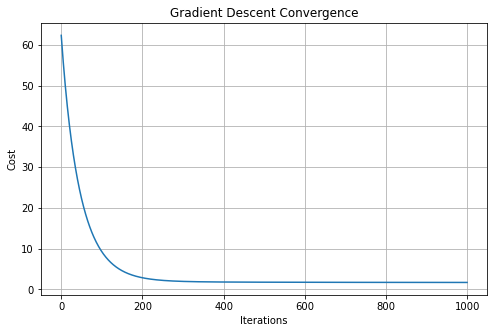

In [32]:
plt.figure(figsize=(8,5))

plt.plot(cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Gradient Descent Convergence")

plt.grid(True)

plt.show()

The cost decreases steadily with each iteration.
This indicates that Gradient Descent is successfully minimizing the loss function.
The model is converging towards the optimal solution.

In [33]:
y_pred = X_test.dot(theta)

The trained model was used to predict the final grades of students in the test dataset.
These predicted values are compared with the actual grades to evaluate model performance.

In [34]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)

print("MSE :", mse)

print("RMSE:", rmse)

print("R2 Score:", r2)

MAE : 1.3822555414605882
MSE : 4.912432134231974
RMSE: 2.2164007160782035
R2 Score: 0.7604281487376789


The MAE indicates that, on average, the model's predicted student final grade differs from the actual grade by approximately 1.38 marks.

Since larger errors are squared, this metric penalizes large prediction errors more heavily.
An MSE of 4.91 indicates that the overall prediction error is relatively low.

An RMSE of 2.21 means that the model's predictions typically differ from the actual grades by about 2.21 marks.
This indicates good predictive performance for the dataset.

The R² score of 0.76 means that the model explains approximately 76.04% of the variation in students' final grades using the selected input features.
This indicates that the Linear Regression model has a good fit

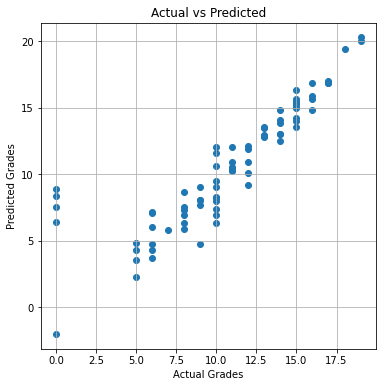

In [35]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Grades")

plt.ylabel("Predicted Grades")

plt.title("Actual vs Predicted")

plt.grid(True)

plt.show()

The predicted grades are close to the actual grades.
The model has good prediction accuracy.

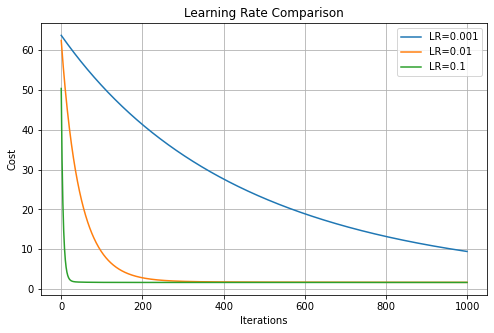

In [36]:
learning_rates = [0.001, 0.01, 0.1]

iterations = 1000

plt.figure(figsize=(8,5))

for lr in learning_rates:

    theta = np.zeros(X_train.shape[1])

    theta, cost_history = gradient_descent(
        X_train,
        y_train.values,
        theta,
        lr,
        iterations
    )

    plt.plot(cost_history, label=f"LR={lr}")

plt.xlabel("Iterations")

plt.ylabel("Cost")

plt.title("Learning Rate Comparison")

plt.legend()

plt.grid(True)

plt.show()

For Learning Rate = 0.001

The cost decreases slowly.
Convergence is stable but requires many iterations.

For Learning Rate = 0.01

The cost decreases smoothly.
This learning rate provides a good balance between speed and stability.

For Learning Rate = 0.1

The cost decreases rapidly.
If the graph remains smooth, convergence is fast.
If the graph oscillates or increases, the learning rate is too high, causing instability.

Convergence
A very small learning rate (0.001) converges slowly.
A moderate learning rate (0.01) converges smoothly and is generally a good choice.
A larger learning rate (0.1) converges much faster but may overshoot or become unstable depending on the dataset.